# Finance Intelligence Agent — Portfolio Demo

## tl;dr

This notebook demonstrates a modular stock-research agent that routes natural-language questions to price, risk, comparison, news, and sentiment workflows. The demo is deterministic and runs offline; production providers use Yahoo Finance and Finnhub.

**Portfolio focus:** modular architecture, dependency injection, explainable metrics, API security, and reproducible testing.

## Context & Methods

The original Colab prototype combined data collection, modeling, API serving, and credentials in one notebook. The refactor separates those concerns into a Python package. For reproducibility, this walkthrough injects fake providers instead of making live requests.

### Key assumptions

- Synthetic prices illustrate software behavior, not investment performance.
- Annualized volatility uses daily returns and a 252-trading-day convention.
- Maximum drawdown is measured from each running peak.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt

from finance_agent import FinanceAgent
from finance_agent.models import NewsItem, PriceSnapshot

## Data

Create deterministic providers with two different price paths and representative headlines.

In [2]:
class DemoMarketData:
    def __init__(self):
        self.prices = {
            "AAPL": [100 + 0.8 * i + (i % 5 - 2) for i in range(60)],
            "MSFT": [100 + 0.7 * i + (i % 3 - 1) * 2 for i in range(60)],
        }

    def price(self, ticker):
        values = self.prices[ticker]
        return PriceSnapshot(ticker, values[-1], values[-2], datetime.now(timezone.utc))

    def history(self, ticker, period="6mo"):
        return pd.DataFrame({"Close": self.prices[ticker]})


class DemoNews:
    def company_news(self, ticker, days=7):
        return [
            NewsItem(f"{ticker} reports strong growth and record profit"),
            NewsItem(f"Analysts upgrade {ticker} after product update"),
        ]


agent = FinanceAgent(DemoMarketData(), DemoNews())

## Results

### 1. Route questions and return concise answers

In [3]:
questions = [
    "How is AAPL trading?",
    "What is AAPL sentiment?",
    "Compare AAPL vs MSFT risk",
]

for question in questions:
    result = agent.ask(question)
    print(f"Q: {question}\nIntent: {result.intent}\nA: {result.answer}\n")

Q: How is AAPL trading?
Intent: price
A: AAPL is +1.22% versus the previous close at $149.20.

Q: What is AAPL sentiment?
Intent: sentiment
A: Recent AAPL news sentiment is positive across 2 articles.

Q: Compare AAPL vs MSFT risk
Intent: compare
A: AAPL has the lowest annualized volatility in this comparison (25.6%).



### 2. Inspect the evidence visually

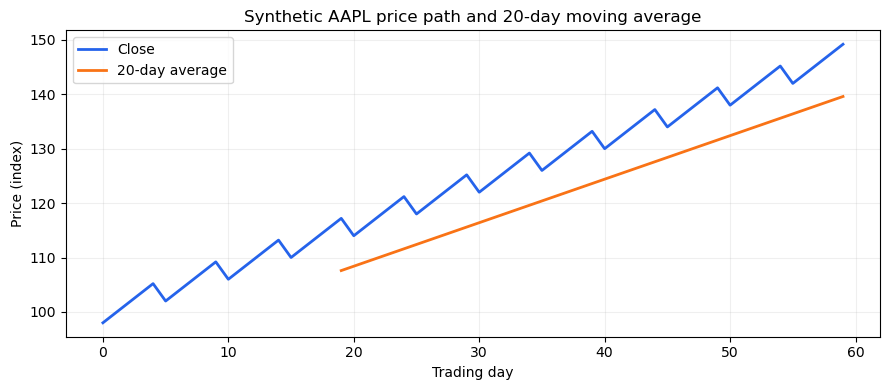

In [4]:
history = agent.market_data.history("AAPL")
ax = history["Close"].plot(figsize=(9, 4), color="#2563EB", linewidth=2)
history["Close"].rolling(20).mean().plot(ax=ax, color="#F97316", linewidth=2)
ax.set(title="Synthetic AAPL price path and 20-day moving average", xlabel="Trading day", ylabel="Price (index)")
ax.legend(["Close", "20-day average"])
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Takeaways

- One agent interface supports multiple research intents while keeping providers replaceable.
- Structured evidence makes each narrative answer auditable.
- Offline fake providers enable fast, deterministic tests and portfolio review.
- Live price and news data can be enabled through the production providers without changing agent logic.

**Important:** outputs are educational research summaries, not financial advice.